# Analyse Train results

L'objectif de ce notebook est d'analyser les résultats d'entraînements obtenus avec le script 2-autoencoder-convolution.
Ces résultats sont sauvegardés dans le fichier 0_train_results.csv.

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("output/2-autoencoder-convolution/0_train_results.csv", sep=",")
df.head()

,date,category,resized_dimension,batch_size,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
0,2026-07-10 19:20:20,bottle,"(128, 128)",16,True,True,convtl,0,mae,mse,0.939748,0.942446,0.500000
1,2026-07-10 19:21:57,transistor,"(128, 128)",16,True,True,convtl,0,mae,mse,0.766667,0.625000,0.200000
2,2026-07-10 19:26:08,cable,"(128, 128)",16,True,True,convtl,0,mae,mse,0.813156,0.619565,0.224138
3,2026-07-10 19:27:27,capsule,"(128, 128)",16,True,True,convtl,0,mae,mse,0.602314,0.293578,0.260870
4,2026-07-10 19:28:41,carpet,"(128, 128)",16,True,True,convtl,0,mae,mse,0.362360,0.258427,0.392857


In [8]:
# Clean data

df["batch_size"] = df["batch_size"].astype(int)
df["resized_dimension"] = df["resized_dimension"].str.extract(r'(\d+)').astype(int)

df = df.replace({True:1, False:0})

In [9]:
# Sort values
df = df.sort_values(["category", "roc_auc"], ascending=[True, False])
df.head()

,date,category,resized_dimension,batch_size,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
106,2026-07-12 17:51:03,bottle,128,8,0,0,convtl_dense,4,mse,mae,0.974101,0.992806,0.60
57,2026-07-11 18:29:26,bottle,128,16,0,0,convtl,0,mse,mae,0.964928,0.971223,0.45
128,2026-07-12 19:33:52,bottle,128,8,1,1,convtl,-1,mse,mae,0.959353,0.985612,0.60
90,2026-07-12 16:38:47,bottle,128,8,0,0,convtl_dense,0,mae,mse,0.950360,0.938849,0.35
122,2026-07-12 19:07:50,bottle,128,8,1,1,convtl_dense,-1,mse,mae,0.944964,0.964029,0.50


In [10]:
bests = df.loc[df.groupby(["category"])["roc_auc"].idxmax()]

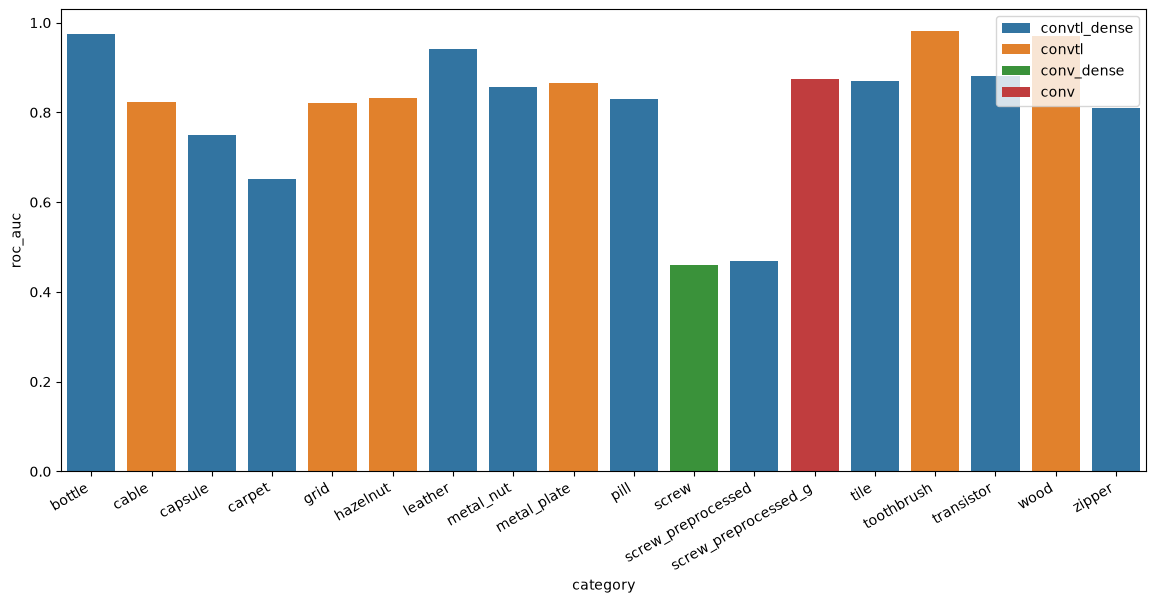

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.barplot(data=bests, x="category", y="roc_auc", hue="model_type")
plt.xticks(rotation=30, ha="right")

plt.legend()
plt.show();

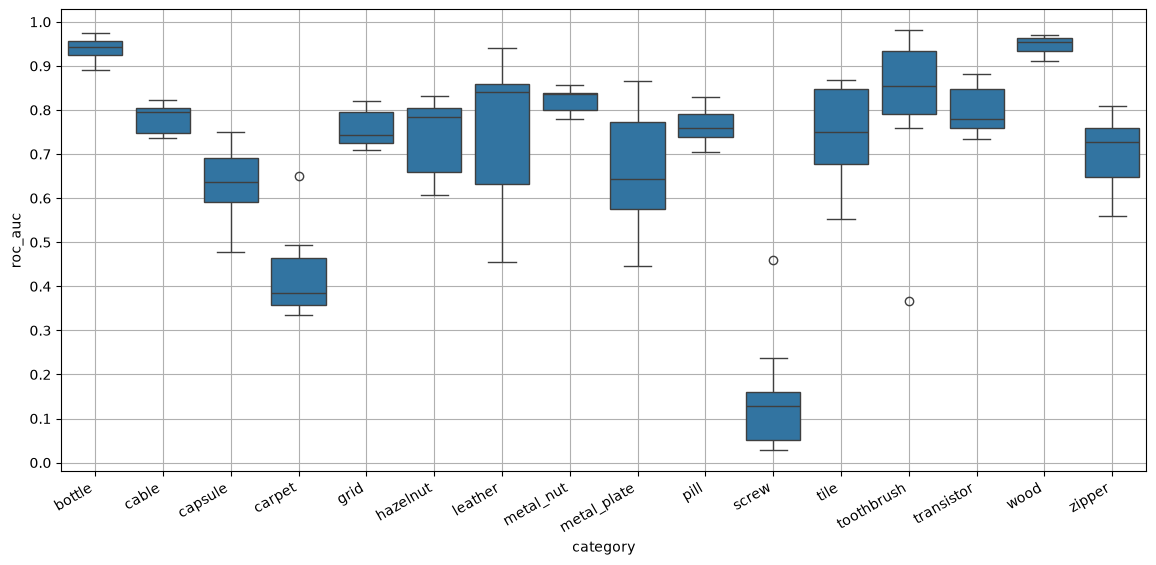

In [57]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="category", y="roc_auc")
plt.xticks(rotation=30, ha="right")

plt.yticks(np.arange(0,1.01,0.1), [f"{y:0.1f}" for y in np.arange(0,1.01,0.1)])
plt.grid(True)
plt.show();

In [58]:
df[df["category"]=="metal_plate"]

,date,category,resized_dimension,batch_size,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
161,2026-07-13 10:51:20,metal_plate,128,8,1,1,convtl,6,mae,mse,0.864732,0.646580,0.123288
159,2026-07-13 10:47:05,metal_plate,128,8,1,0,convtl,6,mae,mse,0.840926,0.625407,0.123288
160,2026-07-13 10:48:59,metal_plate,128,8,0,1,convtl,6,mae,mse,0.840547,0.636808,0.082192
153,2026-07-13 10:29:15,metal_plate,128,8,0,0,convtl,6,mae,mse,0.794219,0.635993,0.136986
146,2026-07-13 10:14:02,metal_plate,128,8,0,0,convtl,4,mae,mse,0.787013,0.642508,0.150685
140,2026-07-13 10:01:21,metal_plate,128,16,1,1,convtl,4,mse,mae,0.778234,0.723941,0.342466
151,2026-07-13 10:25:04,metal_plate,128,8,0,0,convtl,8,mae,mse,0.773248,0.631107,0.150685
152,2026-07-13 10:27:18,metal_plate,128,8,0,0,convtl,2,mae,mse,0.758355,0.639251,0.273973
141,2026-07-13 10:03:07,metal_plate,128,16,0,0,convtl,4,mse,mae,0.744077,0.697883,0.328767
145,2026-07-13 10:12:06,metal_plate,128,8,0,0,convtl,4,mse,mae,0.709440,0.736971,0.534247
